# Taller 2 — Preparación de la información y Análisis Exploratorio de Datos

Este notebook está preparado para ejecutarse en **Google Colab** usando el archivo `sillaut.csv`.

El objetivo no es solamente ejecutar gráficos o cálculos, sino mostrar el razonamiento de preparación de datos revisado en la unidad: calidad de datos, fuentes de información, ETL, análisis exploratorio, tablas de frecuencia, distribuciones y métricas estadísticas.

La lógica general del taller será:

1. Cargar datos desde una fuente externa.
2. Revisar la calidad de los datos: incompletos, ruidosos o inconsistentes.
3. Clasificar variables en numéricas y categóricas.
4. Preparar una copia limpia del dataset.
5. Aplicar Análisis Exploratorio de Datos.
6. Construir frecuencias, distribuciones empíricas y métricas estadísticas.
7. Generar visualizaciones para apoyar la interpretación.


## 1. Importación de librerías

Esta celda prepara el entorno de trabajo. En términos prácticos, corresponde al paso previo a cualquier análisis de datos: disponer de herramientas para cargar, transformar, resumir y visualizar la información.

Se utilizarán:

- `pandas`: manejo de datos en tablas o DataFrames.
- `numpy`: operaciones numéricas.
- `matplotlib` y `seaborn`: visualización de datos.
- `IPython.display`: presentación más clara de tablas en Colab.


In [1]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================
# pandas permite trabajar con datos tabulares similares a una planilla Excel.
# numpy permite realizar cálculos numéricos de forma eficiente.
# matplotlib y seaborn permiten construir gráficos para el análisis exploratorio.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Configuración visual básica para que las tablas y gráficos se vean mejor en Colab.
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid')


## 2. Carga de datos: fuente de información y etapa de extracción

La PPT indica que los datos pueden provenir de distintas fuentes de información. En este taller, la fuente es un archivo CSV llamado `sillaut.csv`.

Desde la lógica ETL, esta etapa corresponde a **E: Extract / Extraer**. Es decir, se toman los datos desde una fuente externa y se cargan en Python para analizarlos.

El código está preparado para dos situaciones:

- Si el archivo ya está en el entorno de Colab, lo lee directamente.
- Si no está, solicita subirlo manualmente.


In [2]:
# ============================================================
# 2. CARGA DE DATOS
# ============================================================
# Archivo esperado para el taller.
# En Google Colab, el archivo debe subirse al panel lateral o mediante files.upload().

ARCHIVO = 'sillaut.csv'

# En algunos entornos de prueba, el archivo puede estar en /mnt/data.
# Esta línea no afecta el uso normal en Google Colab.
rutas_posibles = [ARCHIVO, '/mnt/data/sillaut.csv']

ruta_encontrada = None
for ruta in rutas_posibles:
    if os.path.exists(ruta):
        ruta_encontrada = ruta
        break

# Si el archivo no está disponible, Colab pedirá subirlo.
if ruta_encontrada is None:
    try:
        from google.colab import files
        print('Sube el archivo sillaut.csv')
        files.upload()
        ruta_encontrada = ARCHIVO
    except Exception:
        raise FileNotFoundError('No se encontró sillaut.csv. Sube el archivo al entorno de Colab.')

# Lectura del CSV.
# Esta lectura crea el DataFrame inicial con los datos crudos.
data_raw = pd.read_csv(ruta_encontrada)

print(f'Archivo leído correctamente desde: {ruta_encontrada}')
print(f'Dimensiones iniciales del dataset: {data_raw.shape[0]} filas y {data_raw.shape[1]} columnas')
display(data_raw.head())


Archivo leído correctamente desde: sillaut.csv
Dimensiones iniciales del dataset: 400 filas y 11 columnas


,Ventas,PrecioComp,Ingresos,Presup.Publicidad,Poblacion,PrecioVenta,CalidadUbic,EdadM,NEducacion,Ubicacion,US
0,9.5000,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.2200,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.0600,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.4000,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.1500,141,64,3,340,128,Bad,38,13,Yes,No


## 3. Diccionario de datos

Antes de preparar la información, se debe comprender qué representa cada variable. Esta etapa evita errores de interpretación y permite decidir qué preparaciones son pertinentes.

También permite distinguir entre:

- Variables **cuantitativas o numéricas**, que admiten medidas como media, mediana, varianza o desviación estándar.
- Variables **categóricas o cualitativas**, que se analizan mediante frecuencias absolutas, relativas y acumuladas.


In [3]:
# ============================================================
# 3. DICCIONARIO DE DATOS
# ============================================================
# El diccionario documenta el significado esperado de cada columna.
# Esta práctica es importante porque la preparación de datos depende del contexto.

Diccionario = {
    'Ventas': 'Ventas unitarias del producto, expresadas en miles.',
    'PrecioComp': 'Precio cobrado por la competencia.',
    'Ingresos': 'Nivel de ingresos de la comunidad, expresado en miles.',
    'Presup.Publicidad': 'Presupuesto de publicidad local.',
    'Poblacion': 'Tamaño de la población en la región.',
    'PrecioVenta': 'Precio de venta cobrado por la empresa.',
    'CalidadUbic': 'Calidad de la ubicación de las estanterías: Bad, Medium o Good.',
    'EdadM': 'Edad promedio de la población local.',
    'NEducacion': 'Nivel de educación de la población local.',
    'Ubicacion': 'Indica si la tienda está en ubicación urbana: Yes o No.',
    'US': 'Indica si la tienda está ubicada en Estados Unidos: Yes o No.'
}

diccionario_df = pd.DataFrame({
    'Variable': list(Diccionario.keys()),
    'Descripción': list(Diccionario.values())
})

display(diccionario_df)


,Variable,Descripción
0,Ventas,"Ventas unitarias del producto, expresadas en m..."
1,PrecioComp,Precio cobrado por la competencia.
2,Ingresos,"Nivel de ingresos de la comunidad, expresado e..."
3,Presup.Publicidad,Presupuesto de publicidad local.
4,Poblacion,Tamaño de la población en la región.
5,PrecioVenta,Precio de venta cobrado por la empresa.
6,CalidadUbic,Calidad de la ubicación de las estanterías: Ba...
7,EdadM,Edad promedio de la población local.
8,NEducacion,Nivel de educación de la población local.
9,Ubicacion,Indica si la tienda está en ubicación urbana: ...


## 4. Inspección inicial del dataset

Esta etapa corresponde al inicio del **Análisis Exploratorio de Datos**. Su propósito es revisar la estructura general antes de modificar cualquier dato.

Aquí se observa:

- Número de filas y columnas.
- Primeros y últimos registros.
- Tipos de datos detectados por Python.
- Cantidad de valores no nulos por columna.

Esta revisión permite anticipar problemas de calidad o errores de carga.


In [4]:
# ============================================================
# 4. INSPECCIÓN INICIAL
# ============================================================
# Se trabaja sobre una copia para preservar los datos originales.
# Esto es una buena práctica: nunca modificar directamente la fuente inicial.

df = data_raw.copy()

print('Dimensiones del dataset:')
print(df.shape)

print('\nPrimeras filas:')
display(df.head())

print('\nÚltimas filas:')
display(df.tail())

print('\nInformación estructural del DataFrame:')
df.info()


Dimensiones del dataset:
(400, 11)

Primeras filas:


,Ventas,PrecioComp,Ingresos,Presup.Publicidad,Poblacion,PrecioVenta,CalidadUbic,EdadM,NEducacion,Ubicacion,US
0,9.5000,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.2200,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.0600,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.4000,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.1500,141,64,3,340,128,Bad,38,13,Yes,No



Últimas filas:


,Ventas,PrecioComp,Ingresos,Presup.Publicidad,Poblacion,PrecioVenta,CalidadUbic,EdadM,NEducacion,Ubicacion,US
395,12.5700,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.1400,139,23,3,37,120,Medium,55,11,No,Yes
397,7.4100,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.9400,100,79,7,284,95,Bad,50,12,Yes,Yes
399,9.7100,134,37,0,27,120,Good,49,16,Yes,Yes



Información estructural del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Ventas             400 non-null    float64
 1   PrecioComp         400 non-null    int64  
 2   Ingresos           400 non-null    int64  
 3   Presup.Publicidad  400 non-null    int64  
 4   Poblacion          400 non-null    int64  
 5   PrecioVenta        400 non-null    int64  
 6   CalidadUbic        400 non-null    object 
 7   EdadM              400 non-null    int64  
 8   NEducacion         400 non-null    int64  
 9   Ubicacion          400 non-null    object 
 10  US                 400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


## 5. Clasificación automática de variables

Una preparación básica consiste en separar las variables según su tipo.

Esto es necesario porque no se analizan igual las variables numéricas y las categóricas:

- Las numéricas permiten calcular media, mediana, cuartiles, varianza, desviación estándar y correlaciones.
- Las categóricas se resumen mediante tablas de frecuencia y gráficos de barras.


In [5]:
# ============================================================
# 5. CLASIFICACIÓN DE VARIABLES
# ============================================================
# select_dtypes permite separar columnas según el tipo de dato detectado.

columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
columnas_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()

print('Variables numéricas:')
print(columnas_numericas)

print('\nVariables categóricas:')
print(columnas_categoricas)


Variables numéricas:
['Ventas', 'PrecioComp', 'Ingresos', 'Presup.Publicidad', 'Poblacion', 'PrecioVenta', 'EdadM', 'NEducacion']

Variables categóricas:
['CalidadUbic', 'Ubicacion', 'US']


## 6. Evaluación de calidad de datos

La PPT señala que los datos observados suelen ser **incompletos, ruidosos o inconsistentes**.

En esta sección se revisan tres problemas frecuentes:

1. **Datos incompletos:** presencia de valores faltantes.
2. **Datos duplicados:** registros repetidos que podrían distorsionar frecuencias o métricas.
3. **Datos inconsistentes:** valores fuera de dominio o incompatibles con el significado de la variable.

Esta revisión es una etapa esencial antes de calcular métricas o construir gráficos.


In [6]:
# ============================================================
# 6.1 REVISIÓN DE VALORES FALTANTES
# ============================================================
# Un valor faltante representa información incompleta.
# Si no se revisa, puede afectar promedios, gráficos, tablas de frecuencia o modelos posteriores.

resumen_calidad = pd.DataFrame({
    'tipo_dato': df.dtypes.astype(str),
    'valores_no_nulos': df.notna().sum(),
    'valores_faltantes': df.isna().sum(),
    'porcentaje_faltantes': (df.isna().mean() * 100).round(2),
    'valores_unicos': df.nunique(dropna=False)
})

display(resumen_calidad)

faltantes = df.isna().sum()
faltantes = faltantes[faltantes > 0]

if faltantes.empty:
    print('No se detectaron valores faltantes en el dataset.')
else:
    print('Columnas con valores faltantes:')
    display(faltantes)
    plt.figure(figsize=(10, 5))
    faltantes.sort_values(ascending=False).plot(kind='bar')
    plt.title('Valores faltantes por columna')
    plt.xlabel('Columna')
    plt.ylabel('Cantidad de valores faltantes')
    plt.xticks(rotation=45)
    plt.show()


,tipo_dato,valores_no_nulos,valores_faltantes,porcentaje_faltantes,valores_unicos
Ventas,float64,400,0,0.0000,336
PrecioComp,int64,400,0,0.0000,73
Ingresos,int64,400,0,0.0000,98
Presup.Publicidad,int64,400,0,0.0000,28
Poblacion,int64,400,0,0.0000,275
PrecioVenta,int64,400,0,0.0000,101
CalidadUbic,object,400,0,0.0000,3
EdadM,int64,400,0,0.0000,56
NEducacion,int64,400,0,0.0000,9
Ubicacion,object,400,0,0.0000,2


No se detectaron valores faltantes en el dataset.


In [7]:
# ============================================================
# 6.2 TRATAMIENTO DE VALORES FALTANTES
# ============================================================
# Se crea una copia de trabajo llamada df_limpio.
# Si existieran valores faltantes, se aplicaría una preparación estándar:
# - Variables numéricas: imputación con la mediana, porque es menos sensible a outliers que la media.
# - Variables categóricas: imputación con la moda, porque representa la categoría más frecuente.
# En este dataset concreto no se modifican datos si no existen faltantes.

DF_ORIGINAL_FILAS = df.shape[0]
df_limpio = df.copy()

if df_limpio.isna().sum().sum() > 0:
    for col in columnas_numericas:
        if df_limpio[col].isna().sum() > 0:
            mediana = df_limpio[col].median()
            df_limpio[col] = df_limpio[col].fillna(mediana)
            print(f'{col}: valores faltantes imputados con mediana = {mediana}')
    
    for col in columnas_categoricas:
        if df_limpio[col].isna().sum() > 0:
            moda = df_limpio[col].mode(dropna=True)[0]
            df_limpio[col] = df_limpio[col].fillna(moda)
            print(f'{col}: valores faltantes imputados con moda = {moda}')
else:
    print('No fue necesario imputar valores faltantes.')


No fue necesario imputar valores faltantes.


In [8]:
# ============================================================
# 6.3 REVISIÓN Y ELIMINACIÓN DE DUPLICADOS
# ============================================================
# Un registro duplicado puede inflar frecuencias, alterar promedios y afectar distribuciones.
# La eliminación se realiza solo si existen filas completamente repetidas.

duplicados = df_limpio.duplicated().sum()
print(f'Filas duplicadas detectadas: {duplicados}')

if duplicados > 0:
    df_limpio = df_limpio.drop_duplicates().reset_index(drop=True)
    print(f'Se eliminaron {duplicados} filas duplicadas.')
else:
    print('No fue necesario eliminar duplicados.')

print(f'Filas iniciales: {DF_ORIGINAL_FILAS}')
print(f'Filas después de limpieza: {df_limpio.shape[0]}')


Filas duplicadas detectadas: 0
No fue necesario eliminar duplicados.
Filas iniciales: 400
Filas después de limpieza: 400


## 7. Revisión de inconsistencias y datos ruidosos

Los datos ruidosos son valores que parecen posibles errores, valores extremos u observaciones poco representativas.

En esta etapa no se eliminan automáticamente. Primero se diagnostican, porque un valor extremo puede ser:

- Un error de digitación.
- Una observación real pero poco frecuente.
- Un caso de negocio relevante.

Para detectar posibles outliers se utiliza la regla del **rango intercuartil**, coherente con las métricas estadísticas revisadas en la unidad.


In [9]:
# ============================================================
# 7.1 REVISIÓN DE VALORES NEGATIVOS EN VARIABLES NUMÉRICAS
# ============================================================
# Según el contexto, variables como ventas, precios, población o ingresos
# no deberían tener valores negativos. Esta revisión busca inconsistencias básicas.

negativos = {}
for col in columnas_numericas:
    negativos[col] = int((df_limpio[col] < 0).sum())

negativos_df = pd.DataFrame.from_dict(negativos, orient='index', columns=['cantidad_valores_negativos'])
display(negativos_df)

if negativos_df['cantidad_valores_negativos'].sum() == 0:
    print('No se detectaron valores negativos en las variables numéricas.')


,cantidad_valores_negativos
Ventas,0
PrecioComp,0
Ingresos,0
Presup.Publicidad,0
Poblacion,0
PrecioVenta,0
EdadM,0
NEducacion,0


No se detectaron valores negativos en las variables numéricas.


In [10]:
# ============================================================
# 7.2 REVISIÓN DE DOMINIOS EN VARIABLES CATEGÓRICAS
# ============================================================
# Una variable categórica debe contener valores esperados.
# Por ejemplo, Ubicacion y US deberían contener Yes/No.
# CalidadUbic debería contener Bad, Medium o Good.

valores_esperados = {
    'CalidadUbic': {'Bad', 'Medium', 'Good'},
    'Ubicacion': {'Yes', 'No'},
    'US': {'Yes', 'No'}
}

for col, esperados in valores_esperados.items():
    observados = set(df_limpio[col].dropna().unique())
    no_esperados = observados - esperados
    print(f'{col}')
    print(f'  Valores observados: {sorted(observados)}')
    print(f'  Valores no esperados: {sorted(no_esperados)}')


CalidadUbic
  Valores observados: ['Bad', 'Good', 'Medium']
  Valores no esperados: []
Ubicacion
  Valores observados: ['No', 'Yes']
  Valores no esperados: []
US
  Valores observados: ['No', 'Yes']
  Valores no esperados: []


In [11]:
# ============================================================
# 7.3 DETECCIÓN DE OUTLIERS CON RANGO INTERCUARTIL
# ============================================================
# El IQR se calcula como Q3 - Q1.
# Se consideran posibles outliers los valores menores que Q1 - 1.5*IQR
# o mayores que Q3 + 1.5*IQR.
# Importante: se detectan, pero no se eliminan automáticamente.

outliers_resumen = []

for col in columnas_numericas:
    q1 = df_limpio[col].quantile(0.25)
    q3 = df_limpio[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    cantidad_outliers = ((df_limpio[col] < limite_inferior) | (df_limpio[col] > limite_superior)).sum()
    
    outliers_resumen.append({
        'variable': col,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'posibles_outliers': int(cantidad_outliers)
    })

outliers_df = pd.DataFrame(outliers_resumen)
display(outliers_df)


,variable,Q1,Q3,IQR,limite_inferior,limite_superior,posibles_outliers
0,Ventas,5.3900,9.3200,3.9300,-0.5050,15.2150,2
1,PrecioComp,115.0000,135.0000,20.0000,85.0000,165.0000,2
2,Ingresos,42.7500,91.0000,48.2500,-29.6250,163.3750,0
3,Presup.Publicidad,0.0000,12.0000,12.0000,-18.0000,30.0000,0
4,Poblacion,139.0000,398.5000,259.5000,-250.2500,787.7500,0
5,PrecioVenta,100.0000,131.0000,31.0000,53.5000,177.5000,5
6,EdadM,39.7500,66.0000,26.2500,0.3750,105.3750,0
7,NEducacion,12.0000,16.0000,4.0000,6.0000,22.0000,0


## 8. Preparación de tipos de datos y codificación

Esta etapa corresponde a **T: Transform / Transformar** dentro de ETL.

Se preparan los datos para que Python interprete correctamente cada variable:

- `CalidadUbic` se transforma en variable categórica ordinal, porque Bad < Medium < Good.
- `Ubicacion` y `US` se transforman en variables categóricas nominales.
- Además, se crean versiones binarias `Ubicacion_bin` y `US_bin`, útiles para correlaciones o modelos posteriores.

La codificación no reemplaza las variables originales. Se agregan nuevas columnas para conservar trazabilidad.


In [12]:
# ============================================================
# 8. TRANSFORMACIÓN DE TIPOS Y CODIFICACIÓN
# ============================================================
# Se crea una nueva copia preparada para análisis.
# Esta versión conserva las columnas originales y agrega columnas codificadas.

df_preparado = df_limpio.copy()

# CalidadUbic tiene un orden lógico: Bad < Medium < Good.
orden_calidad = pd.CategoricalDtype(categories=['Bad', 'Medium', 'Good'], ordered=True)
df_preparado['CalidadUbic'] = df_preparado['CalidadUbic'].astype(orden_calidad)

# Ubicacion y US son categorías nominales Yes/No.
df_preparado['Ubicacion'] = df_preparado['Ubicacion'].astype('category')
df_preparado['US'] = df_preparado['US'].astype('category')

# Codificación binaria: Yes = 1, No = 0.
# Esta transformación permite incluir estas variables en análisis numéricos simples.
mapa_binario = {'Yes': 1, 'No': 0}
df_preparado['Ubicacion_bin'] = df_preparado['Ubicacion'].map(mapa_binario).astype(int)
df_preparado['US_bin'] = df_preparado['US'].map(mapa_binario).astype(int)

print('Tipos de datos después de la preparación:')
display(df_preparado.dtypes.to_frame('tipo_dato'))

display(df_preparado.head())


Tipos de datos después de la preparación:


,tipo_dato
Ventas,float64
PrecioComp,int64
Ingresos,int64
Presup.Publicidad,int64
Poblacion,int64
PrecioVenta,int64
CalidadUbic,category
EdadM,int64
NEducacion,int64
Ubicacion,category


,Ventas,PrecioComp,Ingresos,Presup.Publicidad,Poblacion,PrecioVenta,CalidadUbic,EdadM,NEducacion,Ubicacion,US,Ubicacion_bin,US_bin
0,9.5000,138,73,11,276,120,Bad,42,17,Yes,Yes,1,1
1,11.2200,111,48,16,260,83,Good,65,10,Yes,Yes,1,1
2,10.0600,113,35,10,269,80,Medium,59,12,Yes,Yes,1,1
3,7.4000,117,100,4,466,97,Medium,55,14,Yes,Yes,1,1
4,4.1500,141,64,3,340,128,Bad,38,13,Yes,No,1,0


## 9. Tabla de frecuencias para variables categóricas

La tabla de frecuencias permite describir la distribución de una variable categórica.

Se calculan las mismas columnas revisadas en la PPT:

- **Frecuencia absoluta (`fi`)**: cantidad de veces que aparece cada categoría.
- **Frecuencia acumulada (`Fi`)**: suma progresiva de frecuencias absolutas.
- **Frecuencia relativa (`hi`)**: proporción respecto del total.
- **Frecuencia relativa acumulada (`Hi`)**: suma progresiva de proporciones.


In [13]:
# ============================================================
# 9. TABLAS DE FRECUENCIA PARA VARIABLES CATEGÓRICAS
# ============================================================
# Esta función entrega una tabla de frecuencias completa.
# Se usa para variables cualitativas como CalidadUbic, Ubicacion y US.

def tabla_frecuencias_categorica(serie):
    fi = serie.value_counts(dropna=False).sort_index()
    Fi = fi.cumsum()
    hi = fi / len(serie)
    Hi = hi.cumsum()
    
    tabla = pd.DataFrame({
        'fi_frecuencia_absoluta': fi,
        'Fi_frecuencia_acumulada': Fi,
        'hi_frecuencia_relativa': hi,
        'Hi_frecuencia_relativa_acumulada': Hi
    })
    
    tabla['hi_porcentaje'] = tabla['hi_frecuencia_relativa'] * 100
    tabla['Hi_porcentaje_acumulado'] = tabla['Hi_frecuencia_relativa_acumulada'] * 100
    return tabla

for col in ['CalidadUbic', 'Ubicacion', 'US']:
    print(f'\nTabla de frecuencias para: {col}')
    display(tabla_frecuencias_categorica(df_preparado[col]))



Tabla de frecuencias para: CalidadUbic


,fi_frecuencia_absoluta,Fi_frecuencia_acumulada,hi_frecuencia_relativa,Hi_frecuencia_relativa_acumulada,hi_porcentaje,Hi_porcentaje_acumulado
CalidadUbic,,,,,,
Bad,96,96,0.2400,0.2400,24.0000,24.0000
Medium,219,315,0.5475,0.7875,54.7500,78.7500
Good,85,400,0.2125,1.0000,21.2500,100.0000



Tabla de frecuencias para: Ubicacion


,fi_frecuencia_absoluta,Fi_frecuencia_acumulada,hi_frecuencia_relativa,Hi_frecuencia_relativa_acumulada,hi_porcentaje,Hi_porcentaje_acumulado
Ubicacion,,,,,,
No,118,118,0.2950,0.2950,29.5000,29.5000
Yes,282,400,0.7050,1.0000,70.5000,100.0000



Tabla de frecuencias para: US


,fi_frecuencia_absoluta,Fi_frecuencia_acumulada,hi_frecuencia_relativa,Hi_frecuencia_relativa_acumulada,hi_porcentaje,Hi_porcentaje_acumulado
US,,,,,,
No,142,142,0.3550,0.3550,35.5000,35.5000
Yes,258,400,0.6450,1.0000,64.5000,100.0000


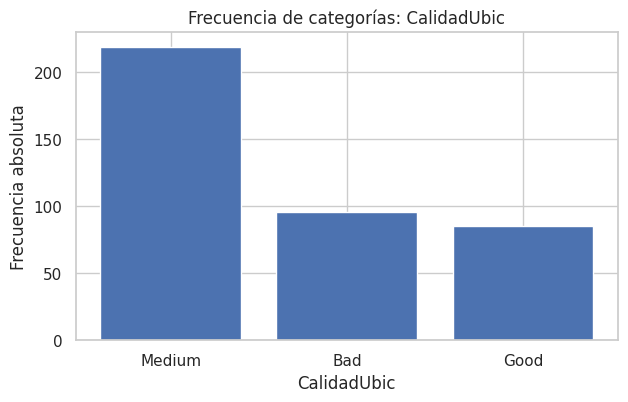

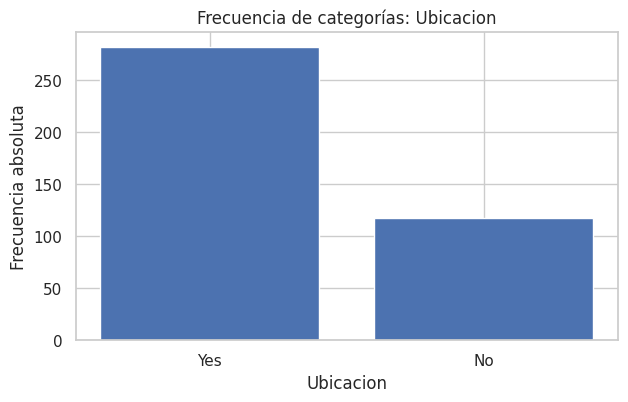

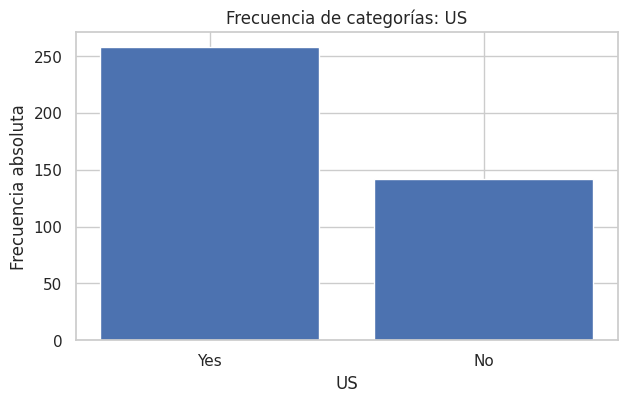

In [14]:
# ============================================================
# 9.1 GRÁFICOS DE BARRAS PARA VARIABLES CATEGÓRICAS
# ============================================================
# Los gráficos de barras permiten comparar visualmente la frecuencia de cada categoría.
# Son adecuados para variables cualitativas.
# Se usa matplotlib de forma directa para evitar problemas de compatibilidad
# entre versiones de pandas, seaborn y variables categóricas ordenadas.

for col in ['CalidadUbic', 'Ubicacion', 'US']:
    frecuencias_col = df_preparado[col].astype(str).value_counts()
    
    plt.figure(figsize=(7, 4))
    plt.bar(frecuencias_col.index, frecuencias_col.values)
    plt.title(f'Frecuencia de categorías: {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia absoluta')
    plt.show()


## 10. Métricas estadísticas para variables numéricas

Las métricas estadísticas permiten resumir el comportamiento de una variable cuantitativa.

Se consideran:

- **Medidas de posición:** mínimo, máximo, media, mediana y cuartiles.
- **Medidas de dispersión:** varianza, desviación estándar, rango intercuartil y coeficiente de variación.
- **Medida de forma:** asimetría, que indica si la distribución está equilibrada o sesgada.


In [15]:
# ============================================================
# 10. RESUMEN ESTADÍSTICO PERSONALIZADO
# ============================================================
# Esta función construye una tabla similar a la revisada en la PPT.
# Se aplica solo a variables numéricas.

def coef_variacion(serie):
    media = serie.mean()
    if media == 0:
        return np.nan
    return serie.std(ddof=1) / media

resumen = []
for col in columnas_numericas:
    s = df_preparado[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    resumen.append({
        'variable': col,
        'n': s.count(),
        'minimo': s.min(),
        'Q1': q1,
        'mediana_Q2': s.median(),
        'media': s.mean(),
        'Q3': q3,
        'maximo': s.max(),
        'IQR': q3 - q1,
        'varianza': s.var(ddof=1),
        'desv_estandar': s.std(ddof=1),
        'coef_variacion': coef_variacion(s),
        'asimetria': s.skew()
    })

resumen_estadistico = pd.DataFrame(resumen)
display(resumen_estadistico)


,variable,n,minimo,Q1,mediana_Q2,media,Q3,maximo,IQR,varianza,desv_estandar,coef_variacion,asimetria
0,Ventas,400,0.0000,5.3900,7.4900,7.4963,9.3200,16.2700,3.9300,7.9756,2.8241,0.3767,0.1856
1,PrecioComp,400,77.0000,115.0000,125.0000,124.9750,135.0000,175.0000,20.0000,235.1472,15.3345,0.1227,-0.0428
2,Ingresos,400,21.0000,42.7500,69.0000,68.6575,91.0000,120.0000,48.2500,783.2182,27.9860,0.4076,0.0494
3,Presup.Publicidad,400,0.0000,0.0000,5.0000,6.6350,12.0000,29.0000,12.0000,44.2273,6.6504,1.0023,0.6396
4,Poblacion,400,10.0000,139.0000,272.0000,264.8400,398.5000,509.0000,259.5000,"21,719.8139",147.3764,0.5565,-0.0512
5,PrecioVenta,400,24.0000,100.0000,117.0000,115.7950,131.0000,191.0000,31.0000,560.5844,23.6767,0.2045,-0.1253
6,EdadM,400,25.0000,39.7500,54.5000,53.3225,66.0000,80.0000,26.2500,262.4496,16.2003,0.3038,-0.0772
7,NEducacion,400,10.0000,12.0000,14.0000,13.9000,16.0000,18.0000,4.0000,6.8672,2.6205,0.1885,0.0440


In [16]:
# ============================================================
# 10.1 EJEMPLO DETALLADO CON LA VARIABLE VENTAS
# ============================================================
# Ventas se usa como variable central para mostrar las medidas revisadas en clases.

variable = 'Ventas'
s = df_preparado[variable]

q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1
cv = coef_variacion(s)

print(f'Variable analizada: {variable}')
print(f'Media: {s.mean():.4f}')
print(f'Mediana: {s.median():.4f}')
print(f'Q1: {q1:.4f}')
print(f'Q3: {q3:.4f}')
print(f'IQR: {iqr:.4f}')
print(f'Varianza: {s.var(ddof=1):.4f}')
print(f'Desviación estándar: {s.std(ddof=1):.4f}')
print(f'Coeficiente de variación: {cv:.4f} ({cv*100:.2f}%)')
print(f'Coeficiente de asimetría: {s.skew():.4f}')


Variable analizada: Ventas
Media: 7.4963
Mediana: 7.4900
Q1: 5.3900
Q3: 9.3200
IQR: 3.9300
Varianza: 7.9756
Desviación estándar: 2.8241
Coeficiente de variación: 0.3767 (37.67%)
Coeficiente de asimetría: 0.1856


## 11. Distribución empírica e histograma

El histograma permite observar cómo se distribuye una variable numérica agrupando los valores en intervalos.

La distribución empírica muestra el comportamiento observado en los datos. No es una distribución teórica como la normal, sino una representación basada en la muestra disponible.

Para seleccionar el número de intervalos se puede usar la **regla de Sturges**:

\[
k = 1 + 3.322 \cdot \log_{10}(n)
\]

Donde `n` es el número de observaciones.


Número de observaciones: 400
Número de intervalos sugerido por Sturges: 10


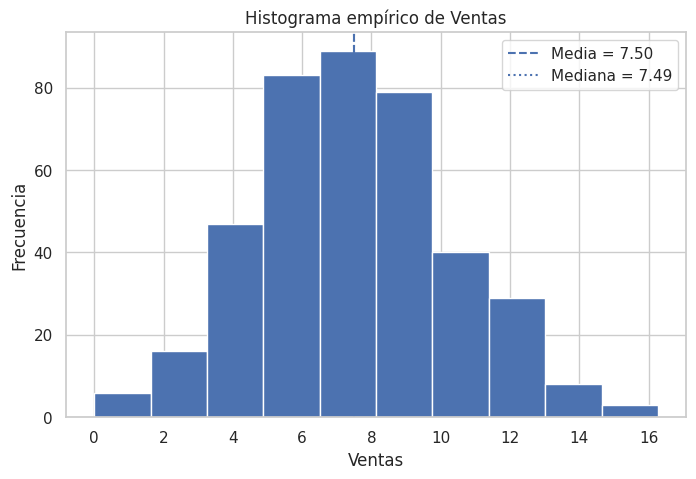

In [17]:
# ============================================================
# 11. HISTOGRAMA CON REGLA DE STURGES
# ============================================================
# La regla de Sturges propone un número razonable de intervalos para el histograma.
# Es útil cuando se quiere construir una tabla de frecuencia para una variable continua.
# Se usa matplotlib directamente para asegurar compatibilidad en Google Colab.

variable = 'Ventas'
s = df_preparado[variable].dropna()
n = len(s)
k_sturges = int(np.ceil(1 + 3.322 * np.log10(n)))

print(f'Número de observaciones: {n}')
print(f'Número de intervalos sugerido por Sturges: {k_sturges}')

plt.figure(figsize=(8, 5))
plt.hist(s, bins=k_sturges)
plt.axvline(s.mean(), linestyle='--', label=f'Media = {s.mean():.2f}')
plt.axvline(s.median(), linestyle=':', label=f'Mediana = {s.median():.2f}')
plt.title('Histograma empírico de Ventas')
plt.xlabel('Ventas')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()


In [18]:
# ============================================================
# 11.1 TABLA DE FRECUENCIA PARA VARIABLE NUMÉRICA
# ============================================================
# Aquí se agrupa Ventas en intervalos usando la cantidad de clases sugerida por Sturges.
# Esto convierte una variable continua en una tabla de frecuencia por rangos.

def tabla_frecuencias_numerica(serie, k=None):
    serie = serie.dropna()
    n = len(serie)
    if k is None:
        k = int(np.ceil(1 + 3.322 * np.log10(n)))
    
    categorias = pd.cut(serie, bins=k, include_lowest=True)
    fi = categorias.value_counts().sort_index()
    Fi = fi.cumsum()
    hi = fi / n
    Hi = hi.cumsum()
    
    tabla = pd.DataFrame({
        'fi_frecuencia_absoluta': fi,
        'Fi_frecuencia_acumulada': Fi,
        'hi_frecuencia_relativa': hi,
        'Hi_frecuencia_relativa_acumulada': Hi
    })
    tabla['hi_porcentaje'] = tabla['hi_frecuencia_relativa'] * 100
    tabla['Hi_porcentaje_acumulado'] = tabla['Hi_frecuencia_relativa_acumulada'] * 100
    return tabla

tabla_ventas = tabla_frecuencias_numerica(df_preparado['Ventas'], k_sturges)
display(tabla_ventas)


,fi_frecuencia_absoluta,Fi_frecuencia_acumulada,hi_frecuencia_relativa,Hi_frecuencia_relativa_acumulada,hi_porcentaje,Hi_porcentaje_acumulado
Ventas,,,,,,
"(-0.0173, 1.627]",6,6,0.0150,0.0150,1.5000,1.5000
"(1.627, 3.254]",16,22,0.0400,0.0550,4.0000,5.5000
"(3.254, 4.881]",47,69,0.1175,0.1725,11.7500,17.2500
"(4.881, 6.508]",83,152,0.2075,0.3800,20.7500,38.0000
"(6.508, 8.135]",89,241,0.2225,0.6025,22.2500,60.2500
"(8.135, 9.762]",79,320,0.1975,0.8000,19.7500,80.0000
"(9.762, 11.389]",40,360,0.1000,0.9000,10.0000,90.0000
"(11.389, 13.016]",29,389,0.0725,0.9725,7.2500,97.2500
"(13.016, 14.643]",8,397,0.0200,0.9925,2.0000,99.2500


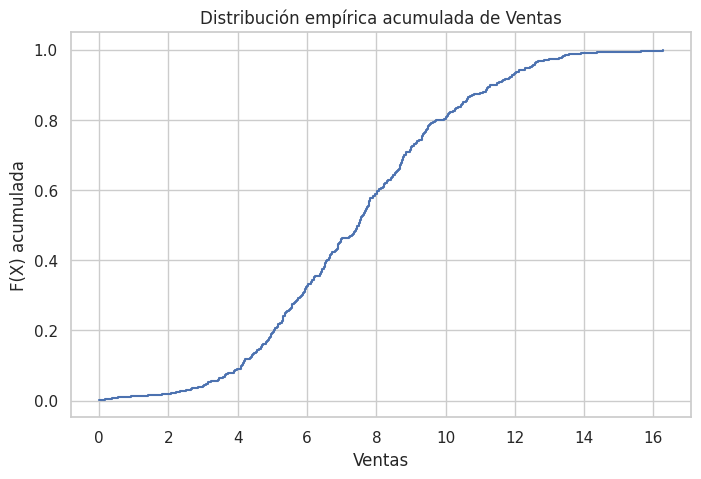

In [19]:
# ============================================================
# 11.2 DISTRIBUCIÓN EMPÍRICA ACUMULADA
# ============================================================
# La ECDF muestra, para cada valor de Ventas, la proporción acumulada de observaciones.
# Permite responder preguntas como: ¿qué porcentaje de observaciones está bajo cierto valor?

ventas_ordenadas = np.sort(df_preparado['Ventas'].dropna())
prob_acumulada = np.arange(1, len(ventas_ordenadas) + 1) / len(ventas_ordenadas)

plt.figure(figsize=(8, 5))
plt.step(ventas_ordenadas, prob_acumulada, where='post')
plt.title('Distribución empírica acumulada de Ventas')
plt.xlabel('Ventas')
plt.ylabel('F(X) acumulada')
plt.show()


## 12. Comparación de ventas según variables categóricas

Una parte relevante del AED es cruzar variables numéricas y categóricas.

En este caso se compara `Ventas` según `CalidadUbic`, `Ubicacion` y `US`. Esto permite observar si las ventas cambian según la ubicación, la calidad de estantería o el país.


/tmp/ipykernel_4713/3097471342.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_por_categoria, labels=categorias)


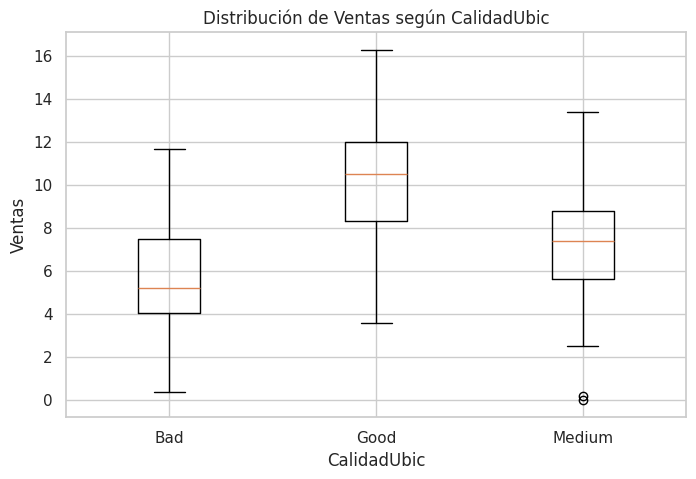

/tmp/ipykernel_4713/3097471342.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_por_categoria, labels=categorias)


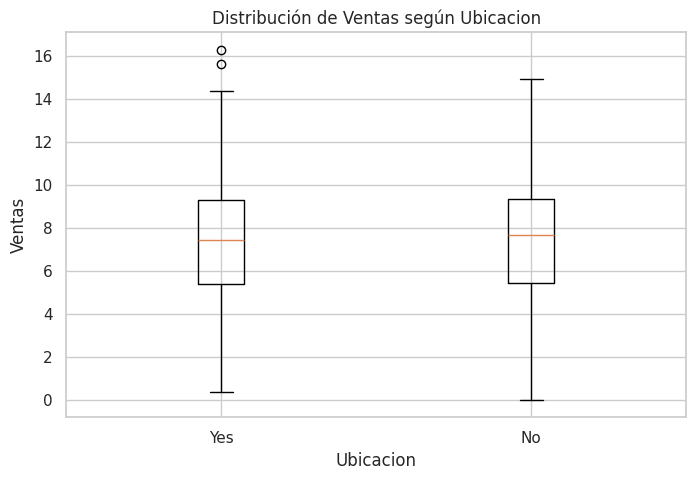

/tmp/ipykernel_4713/3097471342.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_por_categoria, labels=categorias)


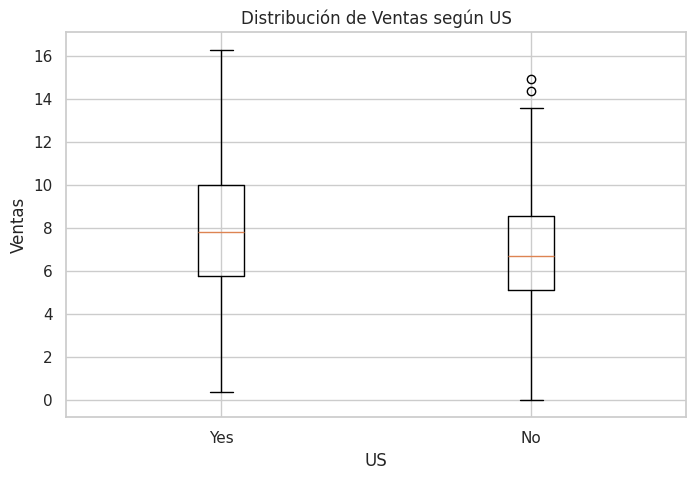

In [20]:
# ============================================================
# 12. BOXPLOTS: VENTAS SEGÚN VARIABLES CATEGÓRICAS
# ============================================================
# El boxplot resume mediana, cuartiles y posibles outliers.
# Es útil para comparar una variable numérica entre grupos categóricos.
# Se usa matplotlib directamente para asegurar compatibilidad entre entornos.

for col in ['CalidadUbic', 'Ubicacion', 'US']:
    categorias = df_preparado[col].astype(str).unique().tolist()
    datos_por_categoria = [df_preparado.loc[df_preparado[col].astype(str) == categoria, 'Ventas'] for categoria in categorias]
    
    plt.figure(figsize=(8, 5))
    plt.boxplot(datos_por_categoria, labels=categorias)
    plt.title(f'Distribución de Ventas según {col}')
    plt.xlabel(col)
    plt.ylabel('Ventas')
    plt.show()


In [21]:
# ============================================================
# 12.1 RESUMEN NUMÉRICO POR GRUPOS
# ============================================================
# Este resumen complementa los boxplots.
# Permite comparar medias, medianas y dispersión de Ventas por categoría.

for col in ['CalidadUbic', 'Ubicacion', 'US']:
    print(f'\nResumen de Ventas por {col}:')
    resumen_grupo = df_preparado.groupby(col, observed=True)['Ventas'].agg(
        n='count',
        media='mean',
        mediana='median',
        desv_estandar='std',
        minimo='min',
        maximo='max'
    )
    display(resumen_grupo)



Resumen de Ventas por CalidadUbic:


,n,media,mediana,desv_estandar,minimo,maximo
CalidadUbic,,,,,,
Bad,96,5.5229,5.2100,2.3563,0.3700,11.6700
Medium,219,7.3066,7.3800,2.2664,0.0000,13.3600
Good,85,10.2140,10.5000,2.5012,3.5800,16.2700



Resumen de Ventas por Ubicacion:


,n,media,mediana,desv_estandar,minimo,maximo
Ubicacion,,,,,,
No,118,7.5636,7.6700,2.8058,0.0000,14.9000
Yes,282,7.4682,7.4200,2.8362,0.3700,16.2700



Resumen de Ventas por US:


,n,media,mediana,desv_estandar,minimo,maximo
US,,,,,,
No,142,6.8230,6.6600,2.6026,0.0000,14.9000
Yes,258,7.8669,7.7900,2.8771,0.3700,16.2700


## 13. Correlación entre variables numéricas

La correlación permite evaluar la relación lineal entre variables numéricas.

Esta matriz no prueba causalidad, pero ayuda a identificar asociaciones que pueden ser relevantes para análisis posteriores, como minería de datos o modelos predictivos.

Para incluir `Ubicacion` y `US`, se usan sus versiones binarias codificadas.


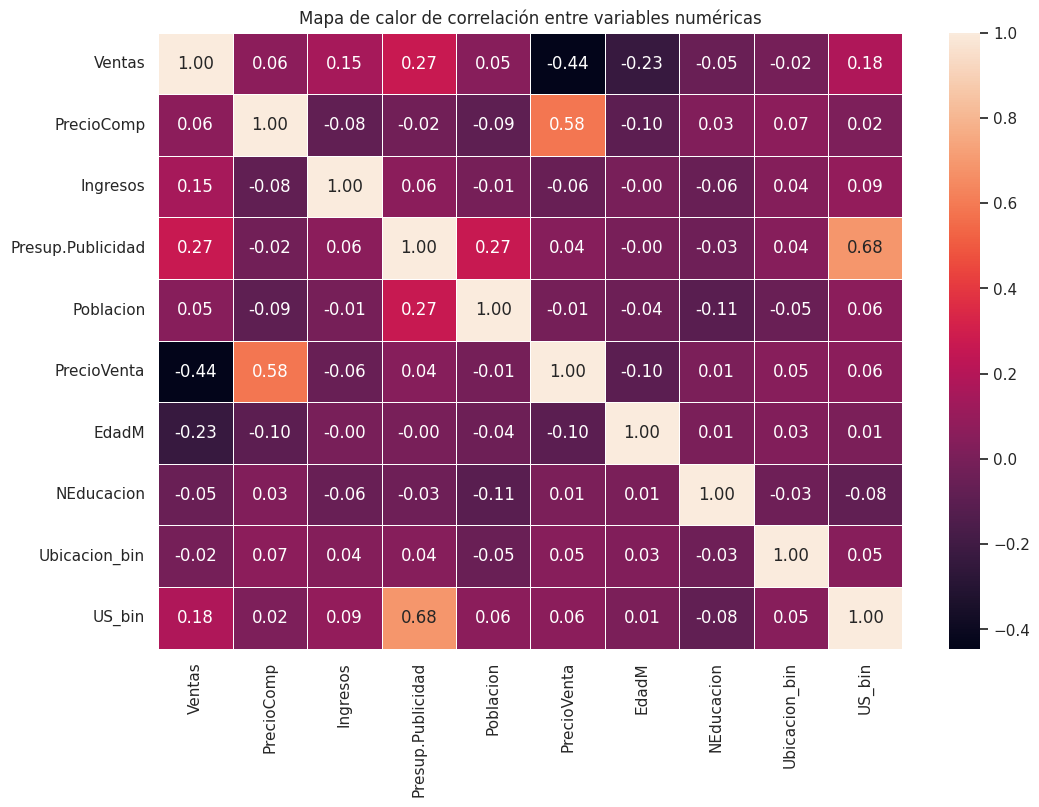

In [22]:
# ============================================================
# 13. MATRIZ DE CORRELACIÓN
# ============================================================
# Se consideran variables numéricas originales y variables binarias preparadas.

columnas_corr = columnas_numericas + ['Ubicacion_bin', 'US_bin']
matriz_corr = df_preparado[columnas_corr].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', linewidths=0.5)
plt.title('Mapa de calor de correlación entre variables numéricas')
plt.show()


## 14. Diagrama de Pareto aplicado al dataset

El diagrama de Pareto ordena las categorías de mayor a menor frecuencia y agrega el porcentaje acumulado.

Su utilidad es identificar qué categorías concentran la mayor proporción de casos. En gestión y análisis de procesos, ayuda a priorizar dónde concentrar la atención.

Aquí se aplica sobre `CalidadUbic`.


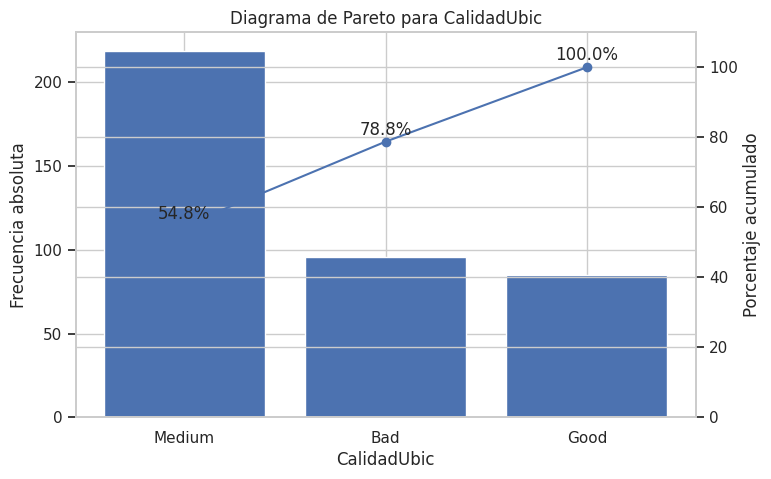

,frecuencia,porcentaje,porcentaje_acumulado
CalidadUbic,,,
Medium,219,54.7500,54.7500
Bad,96,24.0000,78.7500
Good,85,21.2500,100.0000


In [23]:
# ============================================================
# 14. DIAGRAMA DE PARETO
# ============================================================
# Se ordenan las categorías de CalidadUbic desde la más frecuente a la menos frecuente.
# Luego se calcula el porcentaje acumulado.

variable_pareto = 'CalidadUbic'
frecuencias = df_preparado[variable_pareto].value_counts().sort_values(ascending=False)
porcentaje_acumulado = frecuencias.cumsum() / frecuencias.sum() * 100

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.bar(frecuencias.index.astype(str), frecuencias.values)
ax1.set_xlabel(variable_pareto)
ax1.set_ylabel('Frecuencia absoluta')
ax1.set_title(f'Diagrama de Pareto para {variable_pareto}')

ax2 = ax1.twinx()
ax2.plot(frecuencias.index.astype(str), porcentaje_acumulado.values, marker='o')
ax2.set_ylabel('Porcentaje acumulado')
ax2.set_ylim(0, 110)

for i, valor in enumerate(porcentaje_acumulado.values):
    ax2.text(i, valor + 2, f'{valor:.1f}%', ha='center')

plt.show()

pareto_df = pd.DataFrame({
    'frecuencia': frecuencias,
    'porcentaje': frecuencias / frecuencias.sum() * 100,
    'porcentaje_acumulado': porcentaje_acumulado
})

display(pareto_df)


## 15. Interpretaciones automáticas básicas

Esta celda genera una lectura inicial de algunos resultados. No reemplaza el análisis del estudiante, pero entrega una guía para interpretar las salidas del AED.


In [24]:
# ============================================================
# 15. INTERPRETACIÓN INICIAL DEL AED
# ============================================================
# Se generan mensajes básicos usando los resultados calculados.

media_ventas = df_preparado['Ventas'].mean()
mediana_ventas = df_preparado['Ventas'].median()
asim_ventas = df_preparado['Ventas'].skew()
cv_ventas = coef_variacion(df_preparado['Ventas'])

print('Interpretación inicial de Ventas')
print('--------------------------------')
print(f'La media de Ventas es {media_ventas:.2f} y la mediana es {mediana_ventas:.2f}.')

if abs(asim_ventas) < 0.5:
    print(f'La asimetría es {asim_ventas:.2f}, por lo que la distribución parece relativamente equilibrada.')
elif asim_ventas >= 0.5:
    print(f'La asimetría es {asim_ventas:.2f}, lo que sugiere una cola hacia valores altos.')
else:
    print(f'La asimetría es {asim_ventas:.2f}, lo que sugiere una cola hacia valores bajos.')

print(f'El coeficiente de variación es {cv_ventas*100:.2f}%, lo que permite evaluar la dispersión relativa respecto de la media.')

print('\nCategoría más frecuente en CalidadUbic:')
print(df_preparado['CalidadUbic'].value_counts().idxmax())


Interpretación inicial de Ventas
--------------------------------
La media de Ventas es 7.50 y la mediana es 7.49.
La asimetría es 0.19, por lo que la distribución parece relativamente equilibrada.
El coeficiente de variación es 37.67%, lo que permite evaluar la dispersión relativa respecto de la media.

Categoría más frecuente en CalidadUbic:
Medium


## 16. Guardado de resultados preparados

Esta etapa corresponde a **L: Load / Cargar** dentro de ETL, entendida aquí como dejar disponibles los datos preparados y los resúmenes para usos posteriores.

Se generan dos archivos:

- `sillaut_preparado.csv`: dataset limpio y con variables codificadas.
- `resumen_estadistico_sillaut.csv`: tabla resumen de métricas estadísticas.

En Colab, estos archivos quedarán disponibles en el panel lateral para descarga.


In [25]:
# ============================================================
# 16. GUARDADO DE RESULTADOS
# ============================================================
# Guardar resultados permite reutilizar el trabajo de preparación en otros análisis.

df_preparado.to_csv('sillaut_preparado.csv', index=False)
resumen_estadistico.to_csv('resumen_estadistico_sillaut.csv', index=False)

print('Archivos generados:')
print('- sillaut_preparado.csv')
print('- resumen_estadistico_sillaut.csv')


Archivos generados:
- sillaut_preparado.csv
- resumen_estadistico_sillaut.csv


## 17. Cierre del taller

En este notebook se aplicaron las etapas centrales de preparación de la información:

- Carga de datos desde una fuente externa.
- Revisión de calidad: faltantes, duplicados, inconsistencias y outliers.
- Transformación de tipos de datos y codificación.
- Análisis Exploratorio de Datos.
- Tablas de frecuencia para variables categóricas y numéricas.
- Métricas estadísticas de posición, dispersión y forma.
- Visualizaciones: barras, histogramas, ECDF, boxplots, correlación y Pareto.

La preparación de datos es una etapa crítica: si los datos están mal entendidos, incompletos o mal tratados, los resultados posteriores pueden ser técnicamente correctos pero analíticamente inválidos.
